## Descripción del proyecto

Este proyecto tiene el propósito de estudiar los datos de la empresa online Ice cuyo giro es la venta de videojuegos, con alcance en todo el mundo, para identificar patrones que ayuden a determinar si una próxima entrega tendría éxito o no con el fin de planificar estrategicamente campañas publicitarias.

## Importando librerías, cargando DataFrame y revisión general

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats as st

In [2]:
df_games = pd.read_csv('./datasets/games.csv')

In [3]:
# Revisando la estructura general del DataFrame (no. de columnas, nombres de columnas, cantidad de filas, cuenta de datos no nulos y tipo de dato de las columnas)
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


En esta primera revisión con `info()`, se identificaron las siguientes observaciones sobre la estructura inicial del DataFrame:

- Se cuenta con 11 columnas donde el nombre de estas utilizan un formato (ej. `Year_of_Release`, `Critic_Score`, `User_Score`, etc.) que dificultaría la escritura para hacer referencia a ellos cuando se necesiten.
- Hay 6 columnas que cuentan con valores nulos y 5 que cuentan con valores en todas sus filas.

In [4]:
# Revisando la información de los primeros 5 registros
df_games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
print(f'Valores duplicados: {df_games.duplicated().sum()}\n')
print(f'Valores nulos\n{df_games.isna().sum()}')

Valores duplicados: 0

Valores nulos
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


Al extraer los primeros registros puede observarse lo siguiente:
- El tipo de dato para la columna `Year_of_Release` es de tipo flotante cuando lo más indicado para este caso podría ser `object`
- Los valores encontrados en `NA_Sales`, `EU_Sales`, `JP_Sales` y `Other_sales` son de tipo flotante indicando la cantidad de ventas en millones de dólares (`USD`).
- La puntuación de la crítica (`Critic_Score`) se evalúa sobre 100 y es de tipo `float`.
- La puntuación del público (`User_Score`) se evalúa sobre 10 y es de tipo `object`.
- Aunque `Critic_Score` y `User_Score` muestren sus valores con punto decimal, ambas columnas tienen diferentes tipos de datos.
- La columna `Rating` almacena la clasificación de edad basada en la ESRB.


In [6]:
# Revisando una muestra de 10 registros aleatorios
df_games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16563,Razor Freestyle Scooter,GBA,2001.0,Sports,0.01,0.00,0.00,0.00,NaN,NaN,NaN
8890,Deadly Premonition,PS3,2010.0,Action,0.08,0.04,0.00,0.02,NaN,NaN,NaN
11138,FIFA Street 3,DS,2008.0,Sports,0.06,0.02,0.00,0.01,56.0,tbd,E
11892,Petz Fantasy 3D,3DS,2011.0,Simulation,0.07,0.00,0.00,0.00,NaN,tbd,E
15320,The Settlers IV,PC,2001.0,Strategy,0.00,0.02,0.00,0.00,NaN,NaN,NaN
317,MotorStorm,PS3,2006.0,Racing,1.53,1.60,0.06,0.67,84.0,7.4,T
4313,Enemy Territory: Quake Wars,X360,2008.0,Shooter,0.30,0.11,0.00,0.04,69.0,7.3,T
16175,Psycho-Pass,XOne,2014.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
6013,Resident Evil: Revelations 2,PS3,2015.0,Action,0.06,0.05,0.16,0.02,NaN,6.8,M
13809,Harukanaru Toki no Naka de 5,PSP,2011.0,Role-Playing,0.00,0.00,0.04,0.00,NaN,NaN,NaN


Tomándo muestras aleatorias se detectó lo siguiente:
- La ausencia de ventas de un título para cualquiera de las regiones disponibles se registra con `0.0`.
- Hay valores ausentes en `Critic_Score`, `User_Score` y `Rating`.

### Resumen de las observaciones

Después de varias revisiones para la fase inicial de observación de la estructura del DataFrame se puede notar que las columnas no tienen un formato apropiado para las fases de análisis posteriores a la preparación de los datos. También, varias de las columnas necesitan convertirse a un tipo de dato más apropiado y hay tanto valores ausentes o valores posicionales temporales (ej. `tbd`) que se revisará más adelante la forma más apropiada de manejarlos en base a los requerimientos de análisis.

## Preparación de los datos

### Cambiando nombre de las columnas

In [7]:
# Convirtiendo nombres de las columnas en minúscula
df_games.columns = df_games.columns.str.lower()

# Cambiando nombre de la columna `year_of_release`
df_games = df_games.rename(columns= {'year_of_release': 'release_year'})

# Verificando los nuevos nombres de columna
print(df_games.columns.tolist())

['name', 'platform', 'release_year', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### Tratando tipos de dato y valores nulos

#### `genre`

In [8]:
df_games['genre'] = df_games['genre'].fillna('Misc')

Revisando cuenta de valores nulos detecté que habían 2 registros vacíos para esta columna. Al existir un valor de `Misc` para juegos que no tienen una categoría específica, decidí rellenar los valores nulos con esta misma para incluirlos. Cabe mencionar que estos mismos registros corresponden también a los registros de `name` con valores nulos, pero esta acción de agregarlos al género `Misc` ayuda a agrupar esos registros con valores importantes en sus demás columnas.

#### `release_year`

In [9]:
# Convirtiendo tipo de dato para la columna de `release_year`
df_games['release_year'] = df_games['release_year'].astype('Int64').fillna(pd.NA)

El tipo de dato para `release_year` se cambió a `Int64` ya que estos eran `float64` siendo que esto no es lo más adecuado porque los años no se representan así. También, decidí llenar con `NA` los registros con valores nulos para no tomarlos en cuenta en los próximos análisis.

#### `critic_score`

In [10]:
df_games['critic_score'] = (
    df_games['critic_score']
    .astype('Int64')
    .fillna(pd.NA)
)

Se convirtió de `float64` a `Float64` ya que este último puede manejar al mismo tiempo valores flotantes como `NA`. Esto decidí hacerlo de esta manera porque al tratarse de puntuaciones o calificación, si se hacen analisis en base a región, plataforma o año de lanzamiento, esto podría afectar negativamente la calificación general que resulte de las operaciones si estos títulos con calificación `0` se incluyeran. Es mejor dejarlos fuera o ignorarlos.

#### `user_score`

In [11]:
df_games['user_score'] = (
    df_games['user_score']
    .replace('tbd', pd.NA)
    .astype('Float64')
    .fillna(pd.NA)
)

Reemplacé `tbd` por `NA` porque ultimadamente estos valores no podrían considerarse para un análisis sobre `user_score` debido a que representan una ausencia de datos. También, consideré mejor no usar la puntuación sobre 10 calculada desde `critic_score` porque se crearían opiniones falsas de los usuarios donde claramente es complicado que ambas puntuaciones coincidan.

#### `rating`

In [12]:
# Definiendo función para marcar los registros previo a 1994 (antes de la creación de la ESRB)
def pre_esrb(row):
    
    if (
        pd.notna(row['release_year'])
        and row['release_year'] < 1994
        and pd.isna(row['rating'])
        ):
        return 'Pre-ESRB'
    
    return row['rating']
        
    
df_games['rating'] = df_games.apply(pre_esrb, axis=1)

In [13]:
# Reemplazando antiguas califiaciones de la ESRB por la más moderna: E
# y sustituyendo RP (Rating Pending) por NA
standardize_ratings = {
    'K-A': 'E',
    'EC': 'E',
    'RP': np.nan
}

df_games['rating'] = df_games['rating'].replace(standardize_ratings)

# Rellenando valores nulos con la etiqueta 'Unrated'
df_games['rating'] = df_games['rating'].fillna('Unrated')

Para la columna `rating` apliqué una función (`pre_esrb`) que clasifica los juegos anteriores a 1994 (previo al año de la fundación de la ESRB) con la etiqueta `Pre-ESRB`. Esto para identificar fácilmente los registros que habrían sido nulos pero tienen una justificación para no tener una.

También, al revisar las filas me encontré con algunos registros que tenían asignado la clasificación de `K-A` que era la usada anteriormente a `E` (la que a día de hoy sigue usándose); se encontró también `EC` que fue absorvida por `E` debido a la poca utilización de esta por la ESRB.

Finalmente, me pareció adecuado cambiar la clasificación o placeholder de `RP` a `Unrated` ya que ultimadamente denota una ausencia de clasificación. Los valores nulos para los registros faltantes decidí también aplicar la misma etiqueta de `Unrated`.

### Conclusiones de la sección

En conclusión, el tratamiento de estas columnas sirvió para dejar el dataset bien estructurado y sin ruido para los próximos análisis, manteniendo siempre la lógica del negocio. Tras analizar los registros, es muy probable que estas ausencias de datos se deban a problemas de calidad en la recopilación original, desfases tecnológicos entre las plataformas de la época, o simplemente a la falta de cobertura en títulos menos populares, juegos muy antiguos o lanzamientos independientes que no recibieron atención de la prensa ni votaciones del público. 

Rellené los nulos de género con `Misc` para rescatar filas que, aunque no tenían nombre, traían datos financieros importantes en otras variables. Los años de lanzamiento los pasé de `float64` a `Int64` para quitar el punto decimal y dejé sus nulos como `NA` para simplemente ignorarlos en las líneas de tiempo. 

En cuanto a las calificaciones, cambié `critic_score` a `Float64` para manejar nulos nativos y evitar un valor cero que tirara abajo los promedios, mientras que en `user_score` eliminé los `tbd` a favor de `NA` y rechacé calcular notas artificiales basadas en la crítica para no inventar opiniones falsas. Por último, estandaricé la columna de `rating` aplicando una lógica histórica: etiqueté los juegos anteriores a 1994 como `Pre-ESRB` debido a la época, actualicé las clasificaciones viejas como `K-A` y `EC` dentro de la actual `E`, y unifiqué tanto los códigos provisionales `RP` como los nulos restantes bajo la etiqueta `Unrated` al denotar la misma ausencia de clasificación.

### Agregando columna de ventas totales (todas las regiones)

In [14]:
sales_columns = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

df_games['total_sales'] = df_games[sales_columns].sum(axis=1).round(2)

## Análisis exploratorio

### Juegos lanzados anualmente

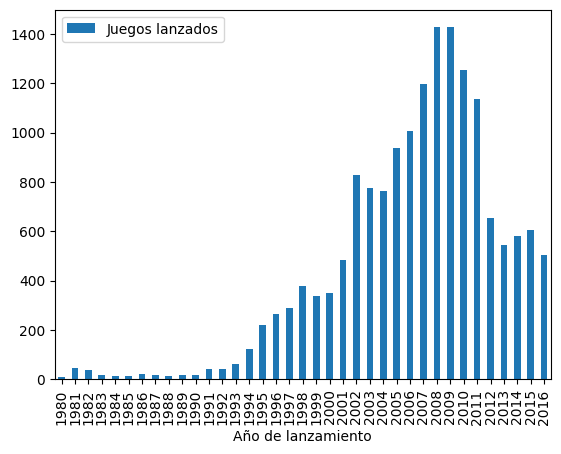

In [15]:
games_yearly_released = df_games.groupby('release_year')['name'].count().reset_index(name='games')

games_yearly_released.plot(x='release_year', y='games', kind='bar')
plt.legend(['Juegos lanzados'])
plt.xlabel('Año de lanzamiento')
plt.show()

Desde 1980 hasta 1990 hay una cantidad de lanzamientos muy pequeña. A partir de 1991 se empieza a notar una tendencia a la alza. Es a partir del año 2002 que los lanzamientos se disparan casi el doble hasta.

Los años que más lanzamientos tuvieron registrados fueron 2008 y 2009. A partir del año siguiente, la cantidad de lanzamientos empieza a disminuir cada vez más.

#### Plataformas con más ventas

In [16]:
# Obteniendo lista de top 10 consolas con más ventas
platform_sales = df_games.groupby('platform')['total_sales'].sum()
top_platforms = platform_sales.sort_values(ascending=False).index[:10].tolist()

top_platforms

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4', 'PSP', 'PC']

In [17]:
# Filtrando filas que contengan cualquiera de los valores de `top_platforms`
df_top_platforms = df_games.loc[df_games['platform'].isin(top_platforms)]


Al filtrar las filas por el top 10 de plataformas con más ventas encontré que algunos juegos que salieron para una determinada consola son ports de una consola anterior. Estas filas tenían en `release _year` el año en que el juego fue lanzado en su consola original en lugar de tener el año de lanzamiento para su respectivo port en el grupo de consolas que conforman parte del top 10.

De dejar estos registros, al querer mostrar la distribución anual de las consolas, estas podrían contener valores fuera de su período de vida real causando que parezcan que algunas de ellas existían desde antes.

In [18]:
platform_release_years = {'PS': 1994, 'PS2': 2000, 'GBA': 2001, 'DS': 2004, 'PSP': 2004, 'X360': 2005, 'PS3': 2006, 'Wii': 2006}

# Condición para filtrar las filas donde el año de lanzamiento del juego sea mayor o igual al año de lanzamiento de la plataforma
platform_release_condition = df_top_platforms['release_year'] >= df_top_platforms['platform'].map(platform_release_years)

df_top_platforms_clean = df_top_platforms[platform_release_condition]

# Dataframe limpio de juegos lanzados en plataformas top 10
df_top_platforms_clean

,name,platform,release_year,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16708,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,0.01,0.00,0.00,0.00,<NA>,<NA>,Unrated,0.01
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,<NA>,<NA>,Unrated,0.00
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,<NA>,Unrated,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,<NA>,Unrated,0.01


#### Distribución de ventas anuales

In [19]:
platform_sales_distribution = df_top_platforms_clean.groupby(['platform', 'release_year'], as_index=False)['total_sales'].sum()

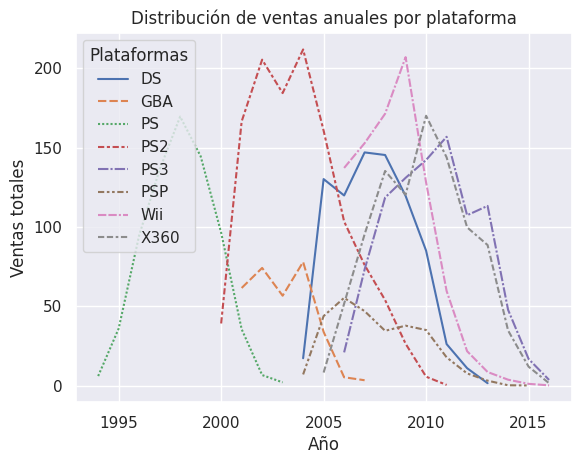

In [20]:
sns.set_theme()
sns.lineplot(data=platform_sales_distribution, x='release_year', y='total_sales', hue='platform', style='platform')
plt.title('Distribución de ventas anuales por plataforma')
plt.xlabel('Año')
plt.ylabel('Ventas totales')
plt.legend(title='Plataformas')
plt.show()
# sns.displot(data=platform_sales_distribution, x='release_year', y='total_sales', hue='platform', col='platform')

In [27]:
platform_sales_pivot = platform_sales_distribution.pivot(
    index='platform',
    columns='release_year',
    values='total_sales'
)

# platform_sales_pivot.drop([2, 6], inplace=True)
platform_sales_pivot

release_year,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.53,74.16,56.67,...,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PS,6.03,35.96,94.7,136.17,169.49,144.53,96.37,35.59,6.67,2.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PS2,NaN,NaN,NaN,NaN,NaN,NaN,39.17,166.43,205.38,184.31,...,75.99,53.90,26.40,5.64,0.45,NaN,NaN,NaN,NaN,NaN
PS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,73.19,118.52,130.93,142.17,156.78,107.36,113.25,47.76,16.82,3.60
PSP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.93,34.55,37.78,35.04,17.82,7.69,3.14,0.24,0.12,NaN
Wii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,152.77,171.32,206.97,127.95,59.65,21.71,8.59,3.75,1.14,0.18
X360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.41,135.26,120.29,170.03,143.84,99.74,88.58,34.74,11.96,1.52


In [37]:
platform_lifespan = platform_sales_pivot.count(axis=1).reset_index(name='lifespan')

platform_lifespan

,platform,lifespan
0,DS,10
1,GBA,7
2,PS,10
3,PS2,12
4,PS3,11
5,PSP,12
6,Wii,11
7,X360,12


In [41]:
print(f'Tiempo de vida promedio: {platform_lifespan['lifespan'].mean().round(2)} años')

Tiempo de vida promedio: 10.62 años
